## Notebook for plotting log2FC boxplots for subset of controls 
- url: http://localhost:8888/tree?token=19656ab27fbdcce014c897e49899de41ed84287591389a1a

In [ ]:
# imports
import matplotlib.pyplot as plt
import pandas as pd
import re # for finding chr_pos_ref_alt
import seaborn as sns
import yaml


# load helpful functions
import sys
sys.path.append('../00_helpful_functions')
import helpful_functions as hf

config_path = "../global80K_config.yaml"
# config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
# load config file
with open(config_path, "r") as f:
    config = yaml.load(f, Loader=yaml.FullLoader)

barcode_threshold = 50

### Checking positive counts for element MPRA in Charlie Gersbach's lab
- looking for positive counts among many cell-types
- load replicate-wise data
- filter based on barcodes (50 barcodes (to be sure))
- plot controls and investigate which were good which were not
- investigating MK even more

In [ ]:
# functions of help:
def has_variant_info_in_header(header):
    """Check if the header has the variant info (chr-pos-ref-alt) in the ending of the header"""
    pattern = r'([A-Z]|[0-9]+)-[0-9]+-[A-Z]-[A-Z]'
    matches = re.search(pattern, header)
    if matches:
        return True
    else: return False


def get_chrom_pos_ref_alt_pattern(header):
    """Returns chrom pos ref alt pattern from a given header"""
    pattern = r'([A-Z]|[0-9]+)-[0-9]+-[A-Z]-[A-Z]'
    matches = re.search(pattern, header)
    if matches:
        return matches.group()
    else: return "NA"

def chengyu_

In [22]:
# read merged data with more than 10 barcodes
replicatewise_counts_mprasnakeflow = pd.read_csv(config['files']['final_design']['merged_mprasnakeflow_counts'], sep="\t")
replicatewise_counts_mprasnakeflow.head()

# add label information
replicatewise_counts_mprasnakeflow['label'] = replicatewise_counts_mprasnakeflow['name'].apply(hf.get_label) # 205657
print(replicatewise_counts_mprasnakeflow.shape)
replicatewise_counts_mprasnakeflow.head()

# add is_variant:
replicatewise_counts_mprasnakeflow['is_variant'] = replicatewise_counts_mprasnakeflow['name'].apply(has_variant_info_in_header)
replicatewise_counts_mprasnakeflow.head()


(205657, 11)


,condition,replicate,name,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,n_obs_bc,label,is_variant
0,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,454,1156,0.117504,0.116267,1.023262,0.033175,112,C_SLEA,False
1,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,427,2429,0.122553,0.270909,2.286043,1.192852,101,C_SLEA,False
2,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,285,746,0.119732,0.121789,1.051910,0.073011,69,C_SLEA,False
3,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,356,1016,0.109784,0.121754,1.146907,0.197749,94,C_SLEA,False
4,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,236,625,0.124384,0.128007,1.064272,0.089867,55,C_SLEA,False


In [ ]:
# filter for beeing control

# # filter for variants
# element_replicatewise_counts_mprasnakeflow = replicatewise_counts_mprasnakeflow.loc[~replicatewise_counts_mprasnakeflow['is_variant']]
# element_replicatewise_counts_mprasnakeflow.shape # (86859, 12)

# how many elements do I expect?

# filter for number of barcodes
filtered_mprasnakeflow_counts = replicatewise_counts_mprasnakeflow.loc[replicatewise_counts_mprasnakeflow['n_obs_bc'] < barcode_threshold]
filtered_mprasnakeflow_counts.head()

,condition,replicate,name,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,n_obs_bc,label,is_variant
5,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,146,429,0.094050,0.107390,1.180835,0.239807,45,C_SLEA,False
6,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,209,604,0.123642,0.138854,1.161383,0.215843,49,C_SLEA,False
7,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|113:...,156,415,0.113053,0.116871,1.069075,0.096363,40,C_SLEA,False
16,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|17:V...,132,465,0.119575,0.163689,1.415675,0.501491,32,C_SLEA,False
17,NGN2,1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|17:V...,31,101,0.089862,0.113773,1.309316,0.388813,10,C_SLEA,False


Plot the violin boxplots

In [31]:
# get label list:
filtered_mprasnakeflow_counts.label.unique()

# DNase is not useful
# negatives are not interesting
labels_without_DNase = ['C_SLEA', 'C_negative_heart_MK', 'C_negative_neuron_MK',
       'C_negative_neuron_NP', 'C_positive_heart_AB',
       'C_positive_heart_CAD', 'C_positive_heart_MK',
       'C_positive_neuron_CD', 'C_positive_neuron_MK',
       'C_positive_neuron_NP', 'GC_Atrial_fib', 'GC_Cort_Chengyu',
       'GC_GABA_Chengyu', 'GC_Glut_Chengyu', 'GC_Hon', 'GC_Kircher',
       'GC_Liang', 'GC_Mendelian_variants', 'GC_Mohlke', 'GC_Selvarajan',
       'GC_Vista', 'MK', 'cardiac_neuro_cava_random']

only_unspecific_element_controls_and_neuro_pos = ['C_SLEA',
       'C_positive_neuron_CD', 'C_positive_neuron_MK',
       'C_positive_neuron_NP', 'GC_Cort_Chengyu',
       'GC_GABA_Chengyu', 'GC_Glut_Chengyu', 'GC_Hon', 'GC_Kircher',
       'GC_Liang', 'GC_Mendelian_variants', 'GC_Mohlke', 'GC_Selvarajan',
       'GC_Vista', 'MK']

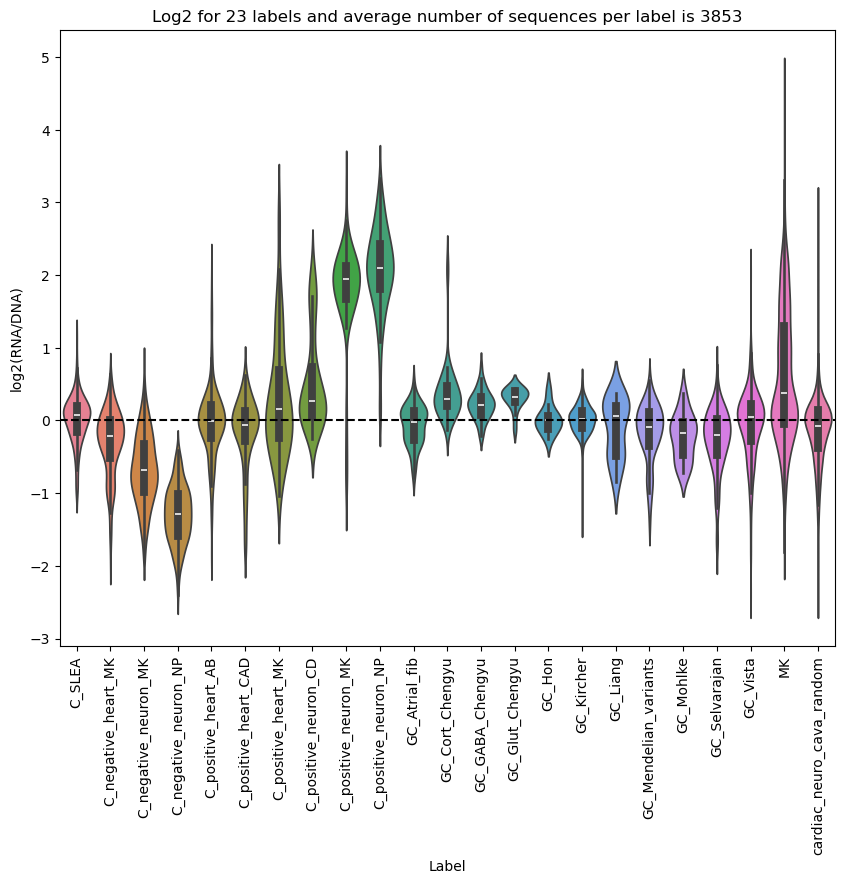

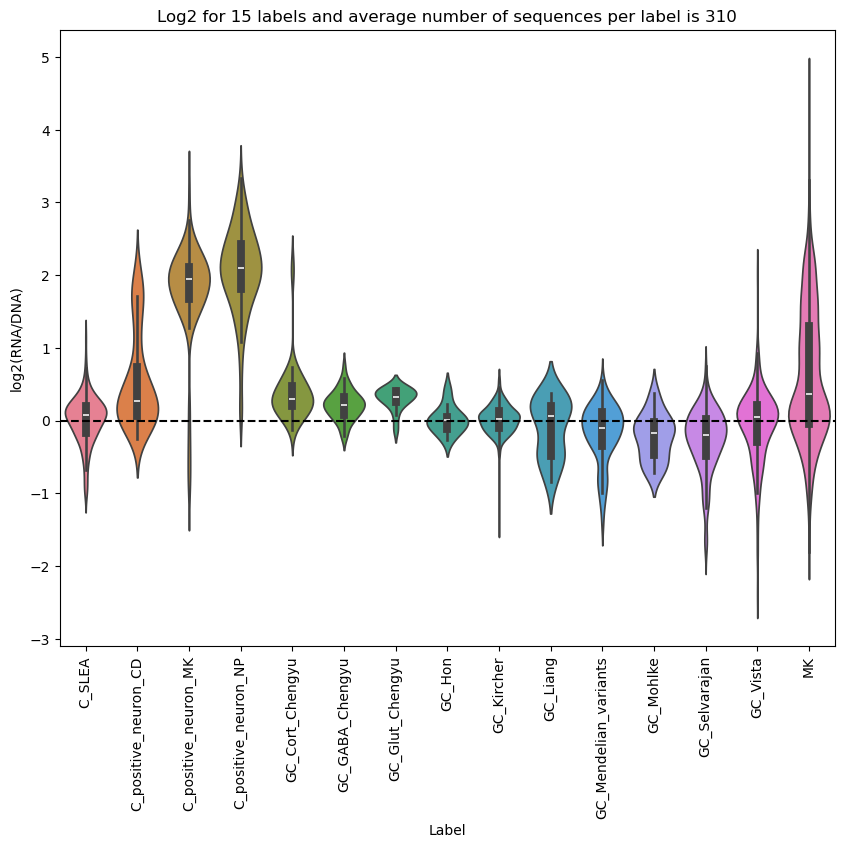

In [ ]:
# function for plotting a specific list of labels as violin plot
def plot_subgroup_violin(count_df, labels_list, save_path=None, alternative_labels=None, colors=None):
    """Plot a violin plot just for a subset of labels
    @colors: dict of colors for each label
    """
    subset_rep_label_df = count_df[count_df["label"].isin(labels_list)]
    avg_seq_per_label = int(subset_rep_label_df.groupby("label").count()["name"].mean())

    fig, ax = plt.subplots(figsize=(10,8))
    ax.set_title(f'Log2 for {len(labels_list)} labels and average number of sequences per label is {avg_seq_per_label}')
    if colors:
        sns.violinplot(x=subset_rep_label_df["label"], y=subset_rep_label_df["log2"], hue=subset_rep_label_df["label"], ax=ax, palette=colors)
    else:
        sns.violinplot(x=subset_rep_label_df["label"], y=subset_rep_label_df["log2"], hue=subset_rep_label_df["label"], ax=ax)

    if alternative_labels:
        # add alternative labels
        ax.set_xticklabels(alternative_labels)
    plt.xticks(rotation=90)
    ax.set_xlabel('Label')
    ax.set_ylabel('log2(RNA/DNA)')
    # add line at 0
    ax.axhline(y=0, color='black', linestyle='--')
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight') # bbox_inches='tight' to prevent cutting off labels

plot_subgroup_violin(filtered_mprasnakeflow_counts, labels_without_DNase, "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/02_controls/activity_distri_without_DNase.png", None, None)
plot_subgroup_violin(filtered_mprasnakeflow_counts, only_unspecific_element_controls_and_neuro_pos, "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/02_controls/activity_distri_only_controls.png", None, None)

# neuro pos + unspecific

In [36]:
gc_glut_chengyu = filtered_mprasnakeflow_counts[filtered_mprasnakeflow_counts['label'] == 'GC_Glut_Chengyu']['name'].to_list()
gc_gaba_chengyu = filtered_mprasnakeflow_counts[filtered_mprasnakeflow_counts['label'] == 'GC_GABA_Chengyu']['name'].to_list()
gc_cort_chengyu = filtered_mprasnakeflow_counts[filtered_mprasnakeflow_counts['label'] == 'GC_Cort_Chengyu']['name'].to_list()

print('glut: ', len(gc_glut_chengyu))
print('gaba: ', len(gc_gaba_chengyu))
print('cort: ', len(gc_cort_chengyu))

['GC_Cort_Chengyu:da|chr14:50985466-50985735|2.13|AstroOligo',
 'GC_Cort_Chengyu:da|chr14:59096407-59096676|2.14|ulEN',
 'GC_Cort_Chengyu:da|chr15:36528366-36528635|2.33|earlyEN',
 'GC_Cort_Chengyu:da|chr20:20551618-20551887|2.29|IN_MGE',
 'GC_Cort_Chengyu:da|chr2:12100504-12100773|2.03|earlyEN',
 'GC_Cort_Chengyu:da|chr2:141595315-141595584|2.43|earlyEN',
 'GC_Cort_Chengyu:da|chr2:152408731-152409000|2.72|ulEN',
 'GC_Cort_Chengyu:da|chr3:116161808-116162077|2.17|IN_CGE',
 'GC_Cort_Chengyu:da|chr3:128102516-128102785|2.08|ulEN',
 'GC_Cort_Chengyu:da|chr3:167383195-167383464|2.15|ulEN',
 'GC_Cort_Chengyu:da|chr3:79734190-79734459|2.08|ulEN',
 'GC_Cort_Chengyu:da|chr3:99863766-99864035|2.12|dlEN',
 'GC_Cort_Chengyu:da|chr5:43007583-43007852|2.22|Microglia',
 'GC_Cort_Chengyu:da|chr5:71446865-71447134|2.15|ulEN',
 'GC_Cort_Chengyu:da|chr5:74432179-74432448|2.2|earlyEN',
 'GC_Cort_Chengyu:da|chr6:135971378-135971647|2.09|dlEN~ulEN',
 'GC_Cort_Chengyu:da|chr6:14317512-14317781|2.23|IN_CGE',

### Previous code with unfiltered counts

In [ ]:
# read data in and investigate counts and labels (standard config)
rep1_path = "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/results/experiments/run1counts_run2Assignment_NoDupAss/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_1_merged_assigned_counts.tsv.gz"
rep2_path = "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/results/experiments/run1counts_run2Assignment_NoDupAss/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_2_merged_assigned_counts.tsv.gz"
rep3_path = "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/experiment/results/experiments/run1counts_run2Assignment_NoDupAss/assigned_counts/assignmentFixDuplicates/standardConfig/NGN2_3_merged_assigned_counts.tsv.gz"
label_path = "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/resources/association_data/design_no_duplicates_sequence_and_header_label.tsv"
count_rep1 = pd.read_csv(rep1_path, sep="\t")
count_rep1["replicate"] = "rep1"
count_rep1.head()
count_rep2 = pd.read_csv(rep2_path, sep="\t")
count_rep2["replicate"] = "rep2"
count_rep2.head()
count_rep3 = pd.read_csv(rep3_path, sep="\t")
count_rep3["replicate"] = "rep3"
count_rep3.head()

label_df = pd.read_csv(label_path, sep="\t")
label_df.head()


,name,label
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random


In [ ]:
# nas in

In [4]:
# combine rep1 - rep3 count data and add replicate column
count_df = pd.concat([count_rep1, count_rep2, count_rep3])
count_df

,name,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,n_obs_bc,replicate
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,416,1024,0.129267,0.127521,0.986492,-0.019621,121,rep1
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,379,2034,0.129547,0.278629,2.150793,1.104869,110,rep1
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,250,671,0.114632,0.123304,1.075646,0.105203,82,rep1
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,300,909,0.112798,0.136972,1.214310,0.280137,100,rep1
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,212,505,0.132851,0.126826,0.954646,-0.066962,60,rep1
...,...,...,...,...,...,...,...,...,...
74896,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,239,1069,0.102860,0.204044,1.983701,0.988195,84,rep3
74897,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,87,250,0.108455,0.138219,1.274434,0.349856,29,rep3
74898,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,71,104,0.082799,0.053789,0.649638,-0.622292,31,rep3
74899,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,376,729,0.118200,0.101638,0.859877,-0.217798,115,rep3


In [6]:
count_df_label = count_df.merge(label_df, on="name", how="left")
count_df_label

,name,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,n_obs_bc,replicate,label
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,416,1024,0.129267,0.127521,0.986492,-0.019621,121,rep1,C_SLEA
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,379,2034,0.129547,0.278629,2.150793,1.104869,110,rep1,C_SLEA
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,250,671,0.114632,0.123304,1.075646,0.105203,82,rep1,C_SLEA
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,300,909,0.112798,0.136972,1.214310,0.280137,100,rep1,C_SLEA
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,212,505,0.132851,0.126826,0.954646,-0.066962,60,rep1,C_SLEA
...,...,...,...,...,...,...,...,...,...,...
224725,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,239,1069,0.102860,0.204044,1.983701,0.988195,84,rep3,cardiac_neuro_cava_random
224726,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,87,250,0.108455,0.138219,1.274434,0.349856,29,rep3,cardiac_neuro_cava_random
224727,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,71,104,0.082799,0.053789,0.649638,-0.622292,31,rep3,cardiac_neuro_cava_random
224728,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,376,729,0.118200,0.101638,0.859877,-0.217798,115,rep3,cardiac_neuro_cava_random


In [7]:
# investigate counts
count_rep1.head()


,name,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,n_obs_bc,replicate
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,416,1024,0.129267,0.127521,0.986492,-0.019621,121,rep1
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,379,2034,0.129547,0.278629,2.150793,1.104869,110,rep1
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,250,671,0.114632,0.123304,1.075646,0.105203,82,rep1
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,300,909,0.112798,0.136972,1.214310,0.280137,100,rep1
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,212,505,0.132851,0.126826,0.954646,-0.066962,60,rep1


In [8]:
# join labels to counts (left join) and make a boxplot and violin plot for log2 ('GC_DNase_positive_shuffeled','GC_DNase_negative_brain_shuffeled','GC_DNase_negative_blood_shuffeled')
count_rep1_label = count_rep1.merge(label_df, on="name", how="left")
count_rep1_label.head()

,name,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,n_obs_bc,replicate,label
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,416,1024,0.129267,0.127521,0.986492,-0.019621,121,rep1,C_SLEA
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,379,2034,0.129547,0.278629,2.150793,1.104869,110,rep1,C_SLEA
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,250,671,0.114632,0.123304,1.075646,0.105203,82,rep1,C_SLEA
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,300,909,0.112798,0.136972,1.214310,0.280137,100,rep1,C_SLEA
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,212,505,0.132851,0.126826,0.954646,-0.066962,60,rep1,C_SLEA


In [9]:

label_groups = count_rep1_label["label"].unique().tolist()
label_groups

['C_SLEA',
 'C_negative_heart_MK',
 'C_negative_neuron_MK',
 'C_negative_neuron_NP',
 'C_positive_heart_AB',
 'C_positive_heart_CAD',
 'C_positive_heart_MK',
 'C_positive_neuron_CD',
 'C_positive_neuron_MK',
 'C_positive_neuron_NP',
 'GC_Atrial_fib',
 'GC_Cort_Chengyu',
 'GC_DNase_negative_blood',
 'GC_DNase_negative_blood_shuffeled',
 'GC_DNase_negative_brain',
 'GC_DNase_negative_brain_shuffeled',
 'GC_DNase_positive',
 'GC_DNase_positive_shuffeled',
 'GC_GABA_Chengyu',
 'GC_Glut_Chengyu',
 'GC_Hon',
 'GC_Kircher',
 'GC_Liang',
 'GC_Mendelian_variants',
 'GC_Mohlke',
 'GC_Selvarajan',
 'GC_Vista',
 'MK',
 'cardiac_neuro_cava_random',
 nan]

/data/gpfs-1/users/kisa11_c/scratch/tmp/hpc-cpu-62/ipykernel_3122649/924498213.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(alternative_labels)


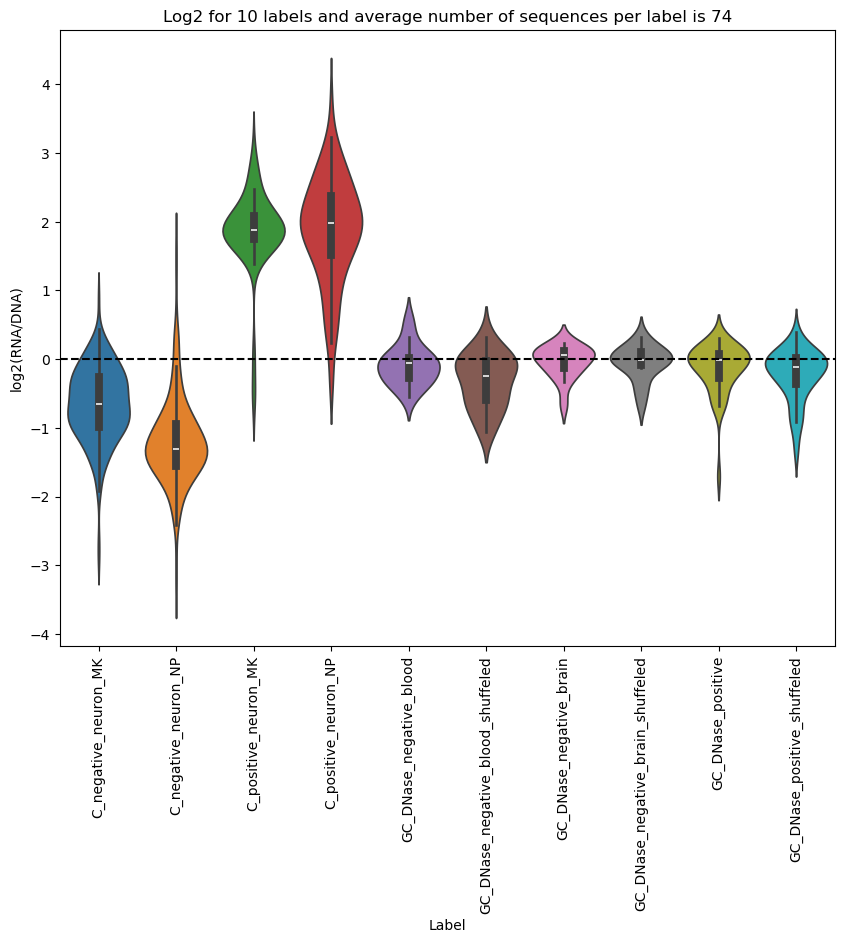

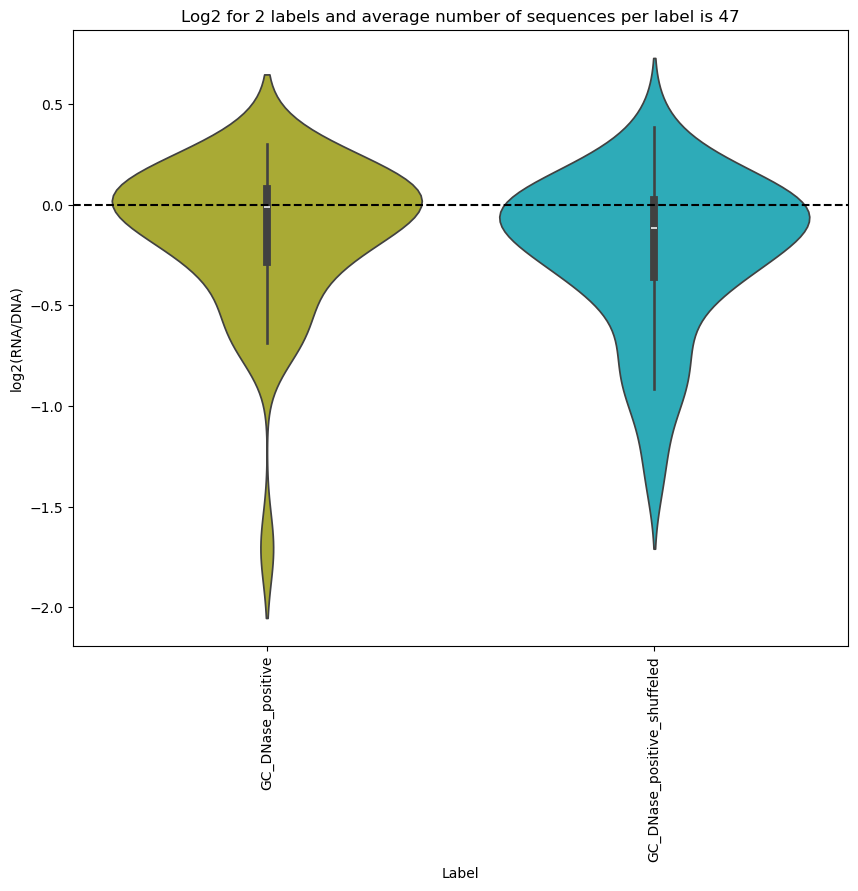

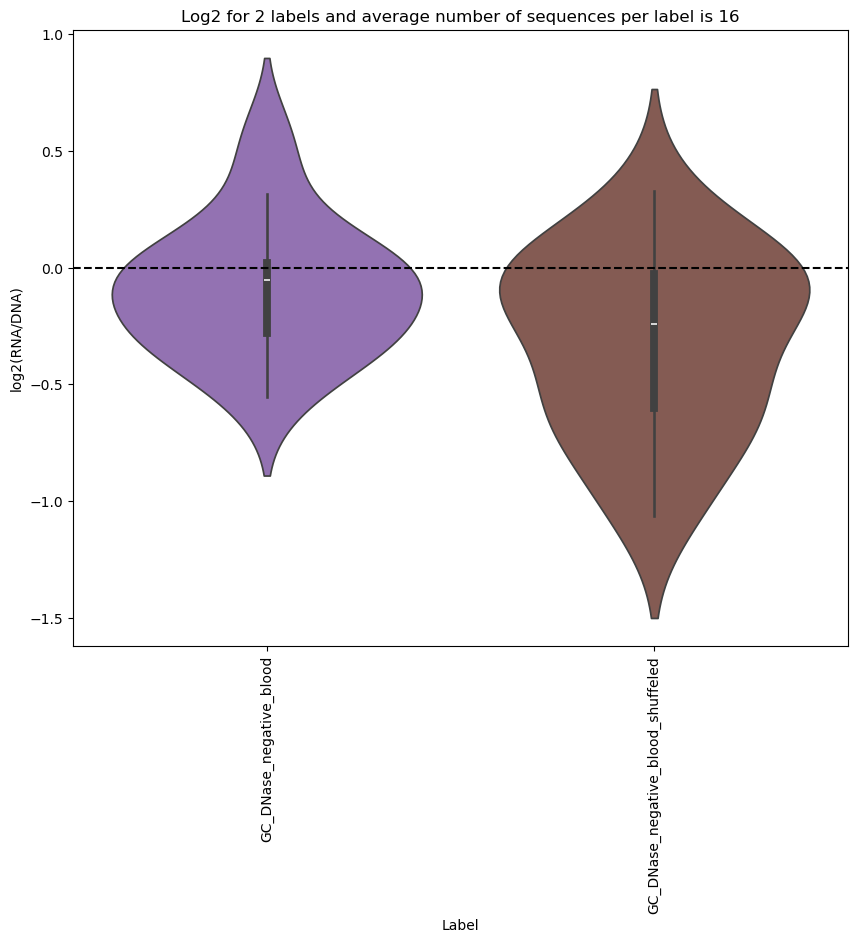

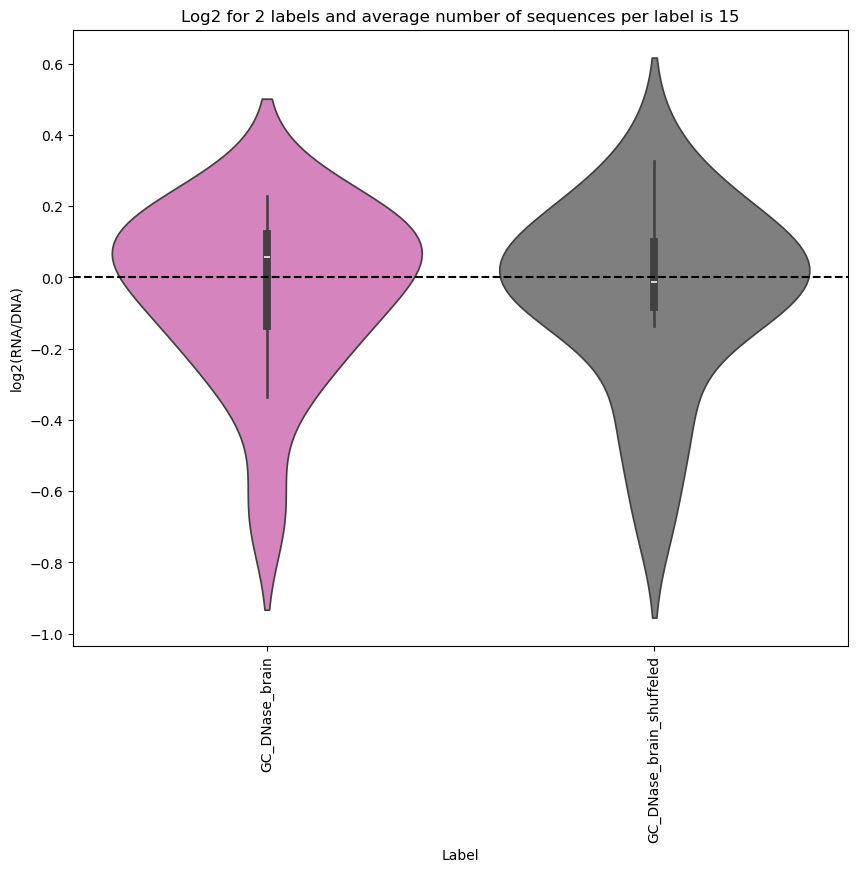

In [ ]:
# function for plotting a specific list of labels as violin plot
def plot_subgroup_violin(labels_list, save_path=None, alternative_labels=None, colors=None):
    """Plot a violin plot just for a subset of labels
    @colors: dict of colors for each label
    """
    subset_rep_label_df = count_rep1_label[count_rep1_label["label"].isin(labels_list)]
    avg_seq_per_label = int(subset_rep_label_df.groupby("label").count()["name"].mean())

    fig, ax = plt.subplots(figsize=(10,8))
    ax.set_title(f'Log2 for {len(labels_list)} labels and average number of sequences per label is {avg_seq_per_label}')
    if colors:
        sns.violinplot(x=subset_rep_label_df["label"], y=subset_rep_label_df["log2"], hue=subset_rep_label_df["label"], ax=ax, palette=colors)
    else:
        sns.violinplot(x=subset_rep_label_df["label"], y=subset_rep_label_df["log2"], hue=subset_rep_label_df["label"], ax=ax)

    if alternative_labels:
        # add alternative labels
        ax.set_xticklabels(alternative_labels)
    plt.xticks(rotation=90)
    ax.set_xlabel('Label')
    ax.set_ylabel('log2(RNA/DNA)')
    # add line at 0
    ax.axhline(y=0, color='black', linestyle='--')
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight') # bbox_inches='tight' to prevent cutting off labels

plot_subgroup_violin(['GC_DNase_negative_blood', 'GC_DNase_negative_blood_shuffeled',
       'GC_DNase_negative_brain', 'GC_DNase_negative_brain_shuffeled',
       'GC_DNase_positive', 'GC_DNase_positive_shuffeled', 'C_negative_neuron_NP', 'C_positive_neuron_MK', 'C_positive_neuron_NP', 'C_negative_neuron_MK'], "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/02_controls/shuffeled_vs_not_shuffeled_controls.png", None, None)

# for keeping the colors
color_dict = {'GC_DNase_negative_blood': sns.color_palette()[0+4], 'GC_DNase_negative_blood_shuffeled': sns.color_palette()[1+4], 'GC_DNase_negative_brain': sns.color_palette()[2+4], 'GC_DNase_negative_brain_shuffeled': sns.color_palette()[3+4], 'GC_DNase_positive': sns.color_palette()[4+4], 'GC_DNase_positive_shuffeled': sns.color_palette()[5+4]}

# all DNase from encode
plot_subgroup_violin(['GC_DNase_positive', 'GC_DNase_positive_shuffeled'], "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/02_controls/GC_DNase_positive_vs_shuffeled.png", None, color_dict)

# all from blood (negative for us)
plot_subgroup_violin(['GC_DNase_negative_blood', 'GC_DNase_negative_blood_shuffeled'], "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/02_controls/GC_DNase_negative_blood_vs_shuffeled.png", None, color_dict)

# all from brain (for 80K positive and shuffeled: negative)
plot_subgroup_violin(['GC_DNase_negative_brain', 'GC_DNase_negative_brain_shuffeled'], "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/02_controls/GC_DNase_negative_brain_vs_shuffeled.png", ['GC_DNase_brain', 'GC_DNase_brain_shuffeled'], color_dict)
# all from brain (for 80K positive and negative)
plot_subgroup_violin(['GC_DNase_negative_brain', 'GC_DNase_negative_brain_shuffeled'], "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/02_controls/GC_DNase_negative_brain_vs_shuffeled.png", ['GC_DNase_brain', 'GC_DNase_brain_shuffeled'], color_dict)


In [13]:
def get_label(header):
    """
    Returns the label of a header. Expected format: <label>:<rest_of_header>
    Can be used by applying on header column of a dataframe.
    """
    return header.split(":")[0]

In [19]:
# investigate variant controls
variant_region_map_path = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/design/final_design/results/final_design/variant_region_map.tsv.gz'
variant_region_map = pd.read_csv(variant_region_map_path, sep="\t")
variant_region_map['label'] = variant_region_map['Variant'].apply(get_label)
control_variant_map = variant_region_map[variant_region_map['label'] != 'cardiac_neuro_cava_random']
pd.DataFrame(control_variant_map['label'].value_counts()).reset_index()

,label,count
0,GC_Selvarajan,198
1,GC_Kircher,198
2,GC_Mendelian_variants,174
3,C_positive_heart_CAD,49
4,GC_Atrial_fib,23
5,GC_Mohlke,20
6,GC_Liang,8
